# ME-433 Rocket Science 
## HW 3 
### Oblique shock calculator 

### Question 1
Write a  function which takes in the incoming Mach number, ratio of specific heats, and turning angle, and outputs the corresponding pressure ratio, temperature ratio, and outgoing Mach number solution for a calorically perfect gas. In creating this function, it is good coding practice to have comments in your code describing the inputs and outputs including units when applicable. Failure to define inputs and outputs will result in loss of some credit.


A python function which : 

+  takes in the **incoming Mach number(M_1), ratio of specific heats(gamma), and turning angle(theta)** 
+  outputs the corresponding **pressure ratio(P), temperature ratio(T), and outgoing Mach number(M_2) solution** 

for a calorically perfect gas(CPG) in the case of **supersonic oblique Shock**

### FUNCTION OBLIQUESHOCK(Incoming Mach number, gamma, theta)
### OUTPUTS float values of [pressure ratio, temperature ratio, and outgoing mach number]

![Beta-Theta Relationship](https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW3/Beta-Theta%20relationship.png?raw=true)


![Oblique Shock relationship equations](https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW3/Oblique%20shock%20Relations.png?raw=true)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Variables 
# M_1 : Incoming Mach number 
# M_2 : Outgoing Mach number
# Theta : turning angle 
# Beta : shock angle 
# Gamma : ratio of specific heats 

#Calculator Procedure 
#1. Calculate the beta angle using the beta-theta relationship 
#1b. Check the given condition to return error value when subsonic
#2. Calculate the pressure ratio, temperature ratio 
#3. Calculate M_2_n, the normal element of the outgoing mach number 
#4. Calculate M_2 using theta and beta angle 

def BetaTheta (m, gamma, theta): 
    Theta = np.deg2rad(theta)
    M = m ** 2
    L = np.sqrt(((M-1) ** 2 - 3 * (1 + ((gamma - 1)/2)*M) * (1 + ((gamma + 1)/2)*M) * np.tan(Theta) ** 2))
    X = ((M - 1) ** 3 - 9*(1 + ((gamma - 1)/2)*M)* (1 + ((gamma - 1)/2)*M + ((gamma+1)/4)* M**2) * (np.tan(Theta) **2))/ (L** 3)

    tanBeta_numerator_weak = M - 1 + 2 * L * np.cos((4*np.pi + np.arccos(X)) / 3)
    tanBeta_numerator_strong = M - 1 + 2 * L * np.cos((np.arccos(X)) / 3)
    tanBeta_denominator = 3 * (1 + ((gamma - 1)/ 2) * M)* np.tan(Theta)
    tanBeta_strong = tanBeta_numerator_strong/tanBeta_denominator
    tanBeta_weak = tanBeta_numerator_weak/tanBeta_denominator
    return np.rad2deg(np.arctan(tanBeta_strong)), np.rad2deg(np.arctan(tanBeta_weak))


In [3]:
#Validation using Virginia Compressible Aeronautics Calculator
# M =5, gamma = 1.4, degrees = 20 
print(BetaTheta(5, 1.4, 20))

(np.float64(84.55625485091416), np.float64(29.800915529155233))


In [ ]:

def ObliqueShock(M_1,gamma, theta): 
    #Function that takes incoming Mach Number(M_1), ratio of specific heats(gamma), and turning angle(theta) 
    #to return pressure ratio(P), temperature ratio(T), and outgoing Mach number(M_2)
    # In the process, calculate normal element of M_1 denoted M_1_n 
    # In the process, calculate density ratio Rho 
    beta_strong, beta_weak = BetaTheta(M_1, gamma, theta)


    # M_1_n and Rho calculation 
    M_1_n = M_1 * np.sin(np.deg2rad(beta_weak))
    Rho = ((gamma + 1) * (M_1_n * M_1_n)) / ((gamma - 1) * (M_1_n * M_1_n)+2)
    P = 1 + (((2 * gamma) / (gamma + 1)) * (M_1_n * M_1_n - 1))
    T = (1 / Rho) * P
    M_2_n_squared = ((M_1_n * M_1_n) + (2 / (gamma - 1))) / ((((2 * gamma) / (gamma - 1)) * (M_1_n * M_1_n)) - 1)
    M_2_n = np.sqrt(M_2_n_squared)
    M_2 = M_2_n / np.sin(np.deg2rad(beta_weak - theta))


    # The stagnation pressure loss for the case of oblique shock should be calculated in the form of stagnation pressure loss in the normal element of M1 
    M = M_1_n ** 2
    stagLoss_pt1 = (((gamma + 1) * M )/((gamma - 1) * M + 2)) ** (gamma/(gamma-1))
    stagLoss_pt2 = ((gamma+1)/(2 * gamma * M - (gamma - 1))) ** (1/(gamma-1))
    stagLoss = stagLoss_pt1 * stagLoss_pt2

    return P, T, M_2, stagLoss
# (1 - StagLoss)

In [58]:
#Validation using Virginia Compressible Aeronautics Calculator
# M =3, gamma = 1.3, theta = 20
print(ObliqueShock(3, 1.3, 20))

(np.float64(3.4921073361288575), np.float64(1.403085191706769), np.float64(2.121132528393494), np.float64(0.8048656742689324))


### Question 2. 
Using this function empirically determine the maximum turning angle for the case of M = 3 and 𝛾 = 1.3. Alternatively you may find an analytical expression for the maximum turning angle. In either case submit the method/work you used to determine your answer.


![Theta-Beta relationship](https://github.com/DanielKim0208/ME-433RocketScience/blob/main/HW3/Theta-Beta%20Relationship.png?raw=true)



C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\2385130062.py:8: RuntimeWarning: divide by zero encountered in divide
  tanTheta = 2 * (1/ np.tan(Beta)) * (M * np.sin(Beta)**2 -1)/(M*(gamma + np.cos(2*Beta))+2)


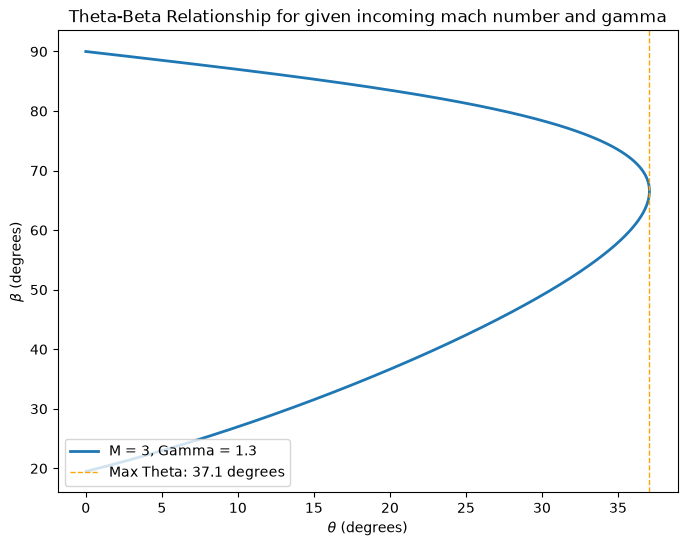

In [60]:
#Variables 
m_q2 = 3
gamma_q2 = 1.3

def Thetabeta (m, gamma, beta): 
    M = m **2 
    Beta = np.deg2rad(beta) 
    tanTheta = 2 * (1/ np.tan(Beta)) * (M * np.sin(Beta)**2 -1)/(M*(gamma + np.cos(2*Beta))+2)
    return np.rad2deg(np.atan(tanTheta))

#Linspace of Theta-Beta angles for calculation
Betarange = np.linspace(0, 90, 50000) 
ThetaRange = Thetabeta(m_q2, gamma_q2, Betarange)
MaxTheta = np.max(ThetaRange)

#I have disregarded all values where Theta <0, which has no values in further analysis
plt.figure(figsize=(8, 6))
plt.plot(ThetaRange[ThetaRange >= 0], Betarange[ThetaRange > 0], linewidth=2, label=f"M = {m_q2}, Gamma = {gamma_q2}")
plt.axvline(x=MaxTheta, color='orange', linestyle='--', linewidth=1, label=f"Max Theta: {MaxTheta:.1f} degrees")
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$\beta$ (degrees)')
plt.title("Theta-Beta Relationship for given incoming mach number and gamma")
plt.legend( loc = 'lower left')


plt.show()

**From the Theta-Beta-M relationship graph, it can be shown that the maximum turning angle for the case of M = 3 and 𝛾 = 1.3 is 37.1 degrees**

### Question 3 
In class it was discussed that it is more “efficient” in terms of stagnation pressure to utilize two oblique shocks to turn a flow than a single oblique shock whose turning angle is equal to the sum of the two. Empirically demonstrate that this is indeed the case for the case of M = 3, 𝛾 = 1.3, and total flow turning of 20 degrees. Plot the stagnation pressure of such a setup as a function of initial step angle from 0 to 20 degrees

C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:21: RuntimeWarning: invalid value encountered in sqrt
  L = np.sqrt(((M-1) ** 2 - 3 * (1 + ((gamma - 1)/2)*M) * (1 + ((gamma + 1)/2)*M) * np.tan(Theta) ** 2))
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:24: RuntimeWarning: invalid value encountered in arccos
  tanBeta_numerator_weak = M - 1 + 2 * L * np.cos((4*np.pi + np.arccos(X)) / 3)
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:25: RuntimeWarning: invalid value encountered in arccos
  tanBeta_numerator_strong = M - 1 + 2 * L * np.cos((np.arccos(X)) / 3)


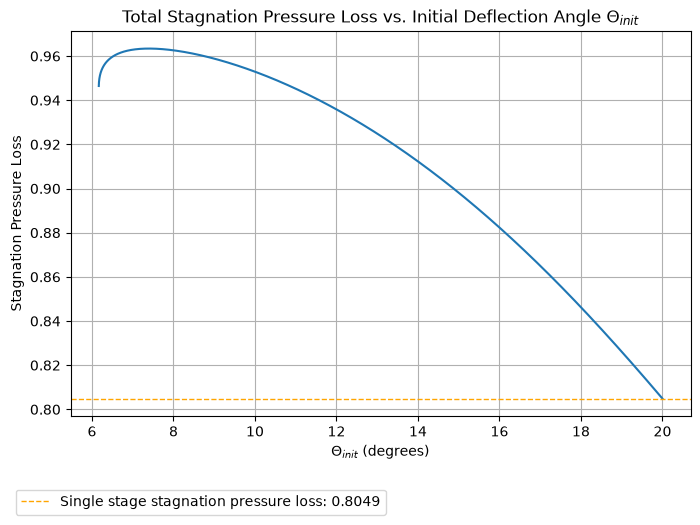

In [ ]:
# Given Parameters
M_q3 = 3
gamma_q3 = 1.3

#Linspace for turning angle split 
Theta_q3 = np.linspace(0.001, 19.999, 50000)
Theta_q3_m3 = 20 - Theta_q3


# (P03/P01) = (P03/P02) * (P02/P01)
M2_q3, a, b, StagLoss_M2_q3 = ObliqueShock(M_q3, gamma_q3, Theta_q3)
M3_q3, c, d, StagLoss_M3_q3 = ObliqueShock(M2_q3, gamma_q3, Theta_q3_m3)
e, f, g, SingleStageStag = ObliqueShock(M_q3, gamma_q3, 20)

TotalStag = StagLoss_M2_q3*StagLoss_M3_q3

# Plot
plt.figure(figsize=(8, 5))
plt.plot(Theta_q3, TotalStag)
plt.axhline(y=SingleStageStag, color='orange', linestyle='--', linewidth=1, label=f"Single stage stagnation pressure loss: {SingleStageStag:.4f}")
plt.xlabel(r'$\Theta_{init}$ (degrees)')
plt.ylabel('Stagnation Pressure Loss')
plt.title('Total Stagnation Pressure Loss vs. Initial Deflection Angle $\\Theta_{init}$')
plt.legend( loc = 'lower left', bbox_to_anchor=(-0.1, -0.275))
plt.grid(True)
plt.show()


### Question 4 
Extend problem 3 from two turns to three turns and plot a 2D surface showing stagnation pressure as a function of the first two step angles.


In [120]:
# Given parameters
M_q4 = 3 
gamma_q4 = 1.3 
Theta_q4_total = 20

#Creating Meshgrid of theta values, so that Ttotal = T2 + T3 > 20

Theta_q4_m2 = np.linspace(0.001, 19.999, 1000)
Theta_q4_m3 = np.linspace(0.001, 19.999, 1000)


Theta_m2, Theta_m3 = np.meshgrid(Theta_q4_m2, Theta_q4_m3)

Theta_m2_valid = Theta_m2[(Theta_q4_total - Theta_m2 - Theta_m3) >= 0]
Theta_m3_valid = Theta_m3[(Theta_q4_total - Theta_m2 - Theta_m3) >= 0]
Theta_m4_valid = Theta_q4_total - Theta_m2_valid - Theta_m3_valid




M_q4_2, a, b, StagLoss_q4_2 = ObliqueShock(M_q4, gamma_q4, Theta_m2_valid)
M_q4_3, c, d, StagLoss_q4_3 = ObliqueShock(M_q4_2, gamma_q4, Theta_m3_valid)
M_q4_4, e, f, StagLoss_q4_4 = ObliqueShock(M_q4_3, gamma_q4, Theta_m4_valid)

TotStagLoss_q4 = StagLoss_q4_2 * StagLoss_q4_3 * StagLoss_q4_4





C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:21: RuntimeWarning: invalid value encountered in sqrt
  L = np.sqrt(((M-1) ** 2 - 3 * (1 + ((gamma - 1)/2)*M) * (1 + ((gamma + 1)/2)*M) * np.tan(Theta) ** 2))
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:24: RuntimeWarning: invalid value encountered in arccos
  tanBeta_numerator_weak = M - 1 + 2 * L * np.cos((4*np.pi + np.arccos(X)) / 3)
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:25: RuntimeWarning: invalid value encountered in arccos
  tanBeta_numerator_strong = M - 1 + 2 * L * np.cos((np.arccos(X)) / 3)
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:27: RuntimeWarning: divide by zero encountered in divide
  tanBeta_strong = tanBeta_numerator_strong/tanBeta_denominator
C:\Users\tanka\AppData\Local\Temp\ipykernel_21352\379748282.py:28: RuntimeWarning: divide by zero encountered in divide
  tanBeta_weak = tanBeta_numerator_weak/tanBeta_denominator
C:\Users\tanka\AppData\L

### Question 5
Is it possible to turn a M = 3, 𝛾 = 1.3 flow by more than the maximum turning angle you calculated in question 2? Give an example of how to achieve this or provide reasoning as to why it is not possible. Note a formal proof of either is not necessary.